tengo que meter aqui una explicacion de loq ue hay en este notebook

**Lectura de los CSS decargados de ESIOS Red Eléctrica España**

In [ ]:
#Paquetes a importar
import pandas as pd #para leer el CSV
import numpy as np #para operaciones numéricas
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

In [ ]:
#Carga de archivos
from google.colab import files
uploaded = files.upload()

Saving ACORUNA_GeneracionMedidaBiogas.csv to ACORUNA_GeneracionMedidaBiogas.csv
Saving LUGO_GeneracionMedidaBiogas.csv to LUGO_GeneracionMedidaBiogas.csv
Saving ORENSE_GeneracionMedidaBiogas.csv to ORENSE_GeneracionMedidaBiogas.csv
Saving PONTEVEDRA_GeneracionMedidaBiogas.csv to PONTEVEDRA_GeneracionMedidaBiogas.csv


In [ ]:
#Lectura de CSVs
# sep=';' le dice a pandas que el separador entre columnas es punto y coma
# selecciono solo las columnas datetime y value
acoruna    = pd.read_csv("ACORUNA_GeneracionMedidaBiogas.csv",    sep=';')[["datetime", "value"]]
lugo       = pd.read_csv("LUGO_GeneracionMedidaBiogas.csv",       sep=';')[["datetime", "value"]]
ourense    = pd.read_csv("ORENSE_GeneracionMedidaBiogas.csv",    sep=';')[["datetime", "value"]]
pontevedra = pd.read_csv("PONTEVEDRA_GeneracionMedidaBiogas.csv", sep=';')[["datetime", "value"]]

In [ ]:
acoruna.head()

,datetime,value
0,2016-04-06T00:00:00+02:00,66.374
1,2016-04-07T00:00:00+02:00,65.878
2,2016-04-08T00:00:00+02:00,71.666
3,2016-04-09T00:00:00+02:00,86.816
4,2016-04-10T00:00:00+02:00,73.969


**Convertir datetime y eliminar zona horaria**

Cada CSV almacena la fecha como texto con zona horaria, pero los registros de invierno llevan +01:00 y los de verano +02:00, lo que impide una conversión directa. Por ello se interpreta primero todo como UTC y luego se convierte a hora de Madrid: sin este paso, al eliminar la zona horaria la fecha quedaría desplazada un día hacia atrás en horario de invierno. Se fuerza medianoche para que todos los registros del mismo día sean idénticos, y finalmente se elimina la zona horaria dejando la columna como datetime64, al formato requerido para operar con fechas en pandas, y quedándonos solamente con los dias, dado que es la única dimensión temporal relevante para este Trabajo.

In [ ]:
for df in [acoruna, lugo, ourense, pontevedra]:
    df["datetime"] = (    #para sobreescribir sobre la col datetime
        pd.to_datetime(df["datetime"], utc=True)  # convierte la columna de etxto en un objeto temporal, y pasa de interpretar el offset de +01:00 y +02:00 a unificar en UTC
        .dt.tz_convert("Europe/Madrid")           # convierte a hora local española (recupera la fecha correcta, ya que los datos son de galicia)
        .dt.normalize()                           # fuerza medianoche por si algún registro no está exactamente a las 00:00
        .dt.tz_localize(None)                     # elimina la zona horaria → resultado: datetime64[ns] limpio para operar en pandas
    )

**Unir los cuatro DataFrames en uno solo par Galicia**

Antes de agregar necesitamos juntar las cuatro tablas provinciales en una sola para poder agrupar por fecha y sumar. Se añade una columna auxiliar que cuenta 1 por cada fila, lo que luego nos permite saber cuántas provincias tenían dato en cada fecha.

In [ ]:
df_total = pd.concat(
    [acoruna, lugo, ourense, pontevedra],  # une los cuatro datasets de las provincias , apilándolas
    ignore_index=True                       # genera un índice nuevo continuo
)

df_total["n_provincias"] = 1  # marca cada fila con 1 para poder contarlas después por fecha

print(f"Filas totales antes de agregar: {len(df_total)}")  # comprueba el total de filas
df_total.head()                                             # muestra las primeras filas

Filas totales antes de agregar: 7155


,datetime,value,n_provincias
0,2016-04-06,66.374,1
1,2016-04-07,65.878,1
2,2016-04-08,71.666,1
3,2016-04-09,86.816,1
4,2016-04-10,73.969,1


**Cobertura provincial por fecha**

Antes de agregar, se comprueba cuántas provincias tienen dato para cada fecha. Esto documenta la heterogeneidad de cobertura que justifica la agregación regional y nos da los números para el TFG.

In [ ]:
conteo = df_total.groupby("datetime")["n_provincias"].sum()  # agrupa als filas por fecha y como cada fila lleva un 1 en n_provincias, sumas y obtienes cuántas provincias reportaron cada día
print("Distribución de provincias con dato por fecha:")
print(conteo.value_counts().sort_index())                    # muestra cuántos días tienen 1, 2, 3 o 4 provincias

Distribución de provincias con dato por fecha:
n_provincias
1     883
2    2012
3     724
4      19
Name: count, dtype: int64


**Agregar a escala regional: crear df_galicia**

Se suman los valores de todas las provincias para cada fecha. Si una provincia no tiene dato ese día simplemente no contribuye a la suma, lo que equivale a asumir generación nula para ella.

In [ ]:
df_galicia = (
    df_total
    .groupby("datetime", as_index=False)["value"]  # agrupa por fecha y selecciona la columna de valores, siendo datetime una columna normal y no un índice
    .sum()                                          # suma los valores disponibles por fecha
    .rename(columns={"value": "generacion_biogas_mwh"})  # renombra la columna con un nombre descriptivo para la serie
    .sort_values("datetime")                        # ordena cronológicamente
    .reset_index(drop=True)                         # resetea el índice
)

**Control de calidad**

Se verifican las propiedades básicas de la base resultante: dimensiones, rango temporal, nulos, duplicados y estadísticos principales. Es el paso que confirma que la construcción ha salido correctamente.

In [ ]:
print("Shape:", df_galicia.shape)                                          # número de filas y columnas
print("Rango temporal:", df_galicia["datetime"].min(), "→", df_galicia["datetime"].max())  # rango de fecha inicial y final
print("\nNulos:", df_galicia.isnull().sum())                               # cuenta valores nulos por columna
print("Duplicados:", df_galicia.duplicated().sum())                        # detecta filas repetidas
print("\nEstadísticos básicos:")
print(df_galicia["generacion_biogas_mwh"].describe().round(2))            # resumen estadístico de la variable objetivo
df_galicia.head(10)                                                        # muestra las primeras 10 filas del dataset

Shape: (3638, 2)
Rango temporal: 2016-04-06 00:00:00 → 2026-03-22 00:00:00

Nulos: datetime                 0
generacion_biogas_mwh    0
dtype: int64
Duplicados: 0

Estadísticos básicos:
count    3638.00
mean       71.80
std        61.57
min        15.62
25%        57.29
50%        67.96
75%        78.12
max      1185.37
Name: generacion_biogas_mwh, dtype: float64


,datetime,generacion_biogas_mwh
0,2016-04-06,78.426
1,2016-04-07,78.660
2,2016-04-08,84.376
3,2016-04-09,100.137
4,2016-04-10,84.765
5,2016-04-11,67.321
6,2016-04-12,75.992
7,2016-04-13,86.749
8,2016-04-14,97.863
9,2016-04-15,107.280


**Guardar la base de datos**

Con la base construida y verificada, se guarda como CSV para poder reutilizarla en los notebooks de análisis y modelado sin repetir todo el proceso.

In [ ]:
df_galicia.to_csv("bbdd_biogas_galicia.csv", index=False)  # guarda el DataFrame como CSV sin incluir el índice

from google.colab import files
files.download("bbdd_biogas_galicia.csv")                  # descarga el archivo al ordenador

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Figura: Evolución diaria de la serie**

Se carga la base ya guardada y se genera la figura de la serie temporal completa.

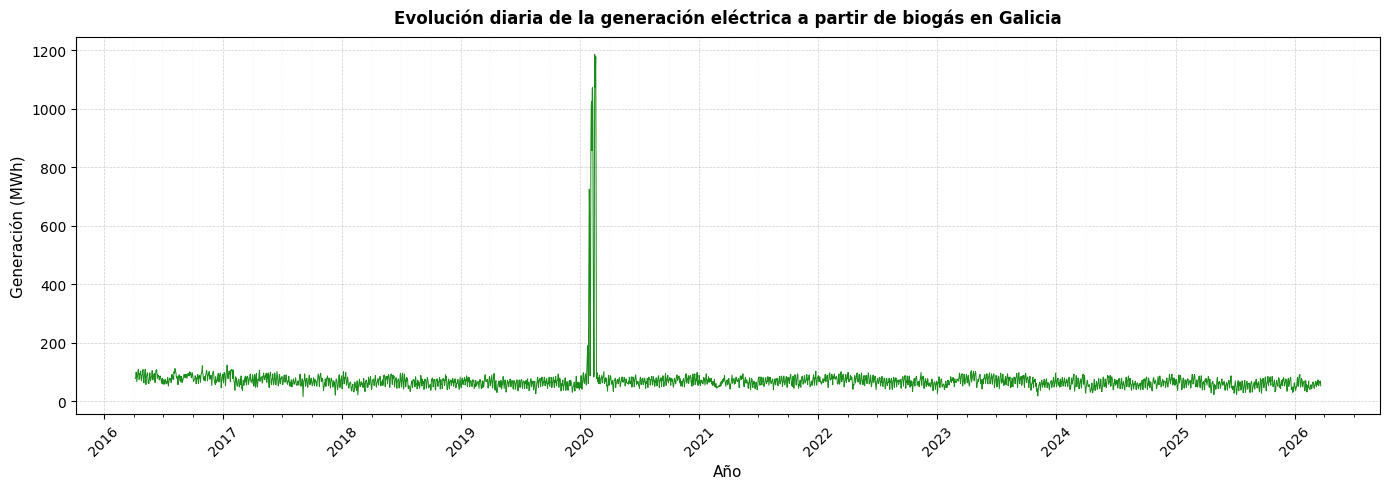

In [ ]:
df_biogas = pd.read_csv("bbdd_biogas_galicia.csv")                        # carga la base guardada
df_biogas["datetime"] = pd.to_datetime(df_biogas["datetime"])             # convierte la fecha a datetime64

fig, ax = plt.subplots(figsize=(14, 5))                                   # crea el lienzo de la figura, y ejes

ax.plot(
    df_biogas["datetime"],
    df_biogas["generacion_biogas_mwh"],
    color="green", linewidth=0.7, alpha=0.9                             # dibuja la serie temporal
)

ax.set_xlabel("Año", fontsize=11)                                         # etiqueta eje X
ax.set_ylabel("Generación (MWh)", fontsize=11)                            # etiqueta eje Y
ax.set_title(
    "Evolución diaria de la generación eléctrica a partir de biogás en Galicia",
    fontsize=12, fontweight="bold", pad=10                                # título en negrita con margen superior
)

ax.xaxis.set_major_locator(mdates.YearLocator())                          # marca un tick por año
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))                  # muestra solo el año en el eje
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))      # ticks menores en abril, julio y octubre

ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)   # cuadrícula principal
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)   # cuadrícula secundaria más suave

plt.xticks(rotation=45)                                                   # rota las etiquetas del eje X
plt.tight_layout()                                                        # ajusta los márgenes automáticamente
plt.savefig("fig_serie_temporal_biogas.png", dpi=300, bbox_inches="tight") # guarda en alta resolución
plt.show()

**Detección de los valores atípicos y representación: Z -  score e IQR**

Se aplican dos métodos para identificar observaciones anómalas.
* El Z-score señala los valores que se alejan más de 3 desviaciones típicas de la media.
* El IQR (rango intercuartílico) marca los que caen 1.5 veces fuera del rango entre el percentil 25 y el percentil 75 [Q1 - 1.5·IQR, Q3 + 1.5·IQR]. Este método no asume que los datos siguen una distribución normal, solo mira dónde está la mitad central y define bordes a partir de ahí.
Se comparan ambos para decidir qué valores tratar.

Adicionalmente, se dibuja la serie completa y se superponen los puntos atípicos de cada método en colores distintos para ver dónde se concentran.
* Rojo = outlier seguro, detectado por Z-score (criterio estricto)
* Naranja = outlier solo por IQR (criterio más amplio, no capturado por Z-score)

In [ ]:
# Calcular Z-score de cada observación
df_biogas["z_score"] = zscore(df_biogas["generacion_biogas_mwh"])

# Marcar outliers: valores con Z-score mayor que 3 en valor absoluto
df_biogas["outlier_z"] = df_biogas["z_score"].abs() > 3

# Calcular límites del método IQR, que es el rango intercuartílico
Q1 = df_biogas["generacion_biogas_mwh"].quantile(0.25)
Q3 = df_biogas["generacion_biogas_mwh"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR #calcula los límites que hace que marquen los ouliers
limite_superior = Q3 + 1.5 * IQR

# Marcar outliers por IQR (solo los que NO están ya marcados por Z-score, para no contar el mismo punto dos veces)
df_biogas["outlier_iqr"] = (
    (df_biogas["generacion_biogas_mwh"] < limite_inferior) |
    (df_biogas["generacion_biogas_mwh"] > limite_superior)
) & ~df_biogas["outlier_z"] #conservo los atípicos detectados por IQR que no estaban ya detectados por Z-score

print(f"Outliers Z-score (|z| > 3): {df_biogas['outlier_z'].sum()}")
print(f"Outliers adicionales por IQR: {df_biogas['outlier_iqr'].sum()}")
print(f"Rango normal IQR: [{limite_inferior:.2f}, {limite_superior:.2f}] MWh")

Outliers Z-score (|z| > 3): 20
Outliers adicionales por IQR: 19
Rango normal IQR: [26.03, 109.37] MWh


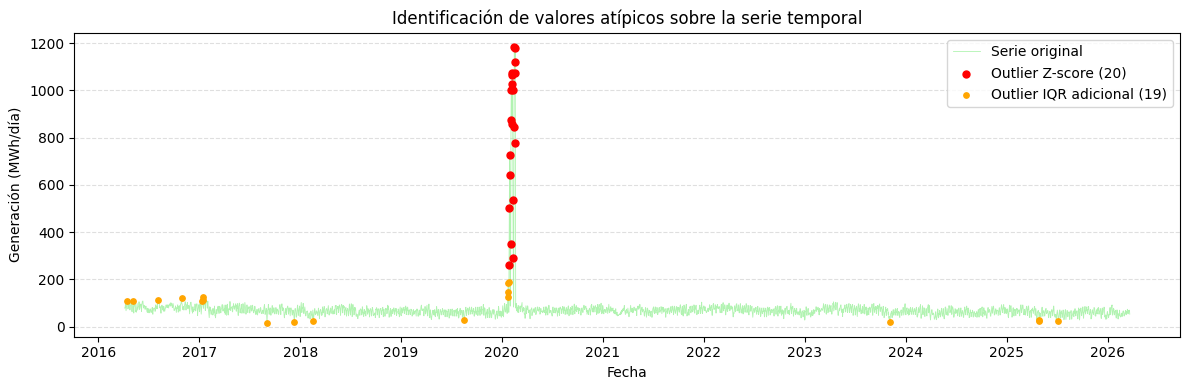

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

# Serie completa
ax.plot(df_biogas["datetime"], df_biogas["generacion_biogas_mwh"],
        linewidth=0.6, color="#90EE90", alpha=0.7, label="Serie original")

# Outliers Z-score en rojo
outliers_z = df_biogas[df_biogas["outlier_z"]]
ax.scatter(outliers_z["datetime"], outliers_z["generacion_biogas_mwh"],
           color="red", s=25, zorder=5, label=f"Outlier Z-score ({len(outliers_z)})") # s controla el tamaño del punto, zorder controla qué elementos quedan por encima de otros, label alimenta la leyenda.

# Outliers solo IQR en naranja
outliers_iqr = df_biogas[df_biogas["outlier_iqr"]]
ax.scatter(outliers_iqr["datetime"], outliers_iqr["generacion_biogas_mwh"],
           color="orange", s=15, zorder=4, label=f"Outlier IQR adicional ({len(outliers_iqr)})")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación (MWh/día)")
ax.set_title("Identificación de valores atípicos sobre la serie temporal")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_outliers_detectados.png", dpi=150, bbox_inches="tight")
plt.show()

**Tratamiento de los valores atípicos**

Los valores atípicos confirmados (Z-score > 3) se sustituyen por NaN.
La interpolación lineal reconstruye cada punto a partir de sus vecinos más próximos.
Se tratan solamente los atípicos identificados por Z-score porque el objetivo es corregir únicamente el error de datos, no toda la variabilidad extrema real, que es el pico de 2020.
El resultado se guarda como serie corregida. A partir de aquí se trabaja con ella.

In [ ]:
# Crea una copia de la serie original y trabaja sobre ella después
df_biogas["generacion_corregida"] = df_biogas["generacion_biogas_mwh"].copy()

# Poner NaN, nulo, donde hay outlier marcado por Z-score
df_biogas.loc[df_biogas["outlier_z"], "generacion_corregida"] = np.nan

# Rellenar los NaN con interpolación lineal entre los valores vecinos, usando la tendencia entre el punto anterior y el posterior
df_biogas["generacion_corregida"] = df_biogas["generacion_corregida"].interpolate(method="linear")

# Verificar que no quedan valores nulos por rellenar
nulos = df_biogas["generacion_corregida"].isna().sum()
print(f"Valores nulos tras interpolación: {nulos}")
print(f"Máximo tras corrección: {df_biogas['generacion_corregida'].max():.2f} MWh")
print(f"Máximo original:        {df_biogas['generacion_biogas_mwh'].max():.2f} MWh")

Valores nulos tras interpolación: 0
Máximo tras corrección: 190.71 MWh
Máximo original:        1185.37 MWh


**Comparación antes y después de la corrección**

Se muestran las dos series en paneles apilados con la misma escala vertical.
Permite verificar visualmente que la interpolación elimina el pico sin distorsionar el resto de la serie.

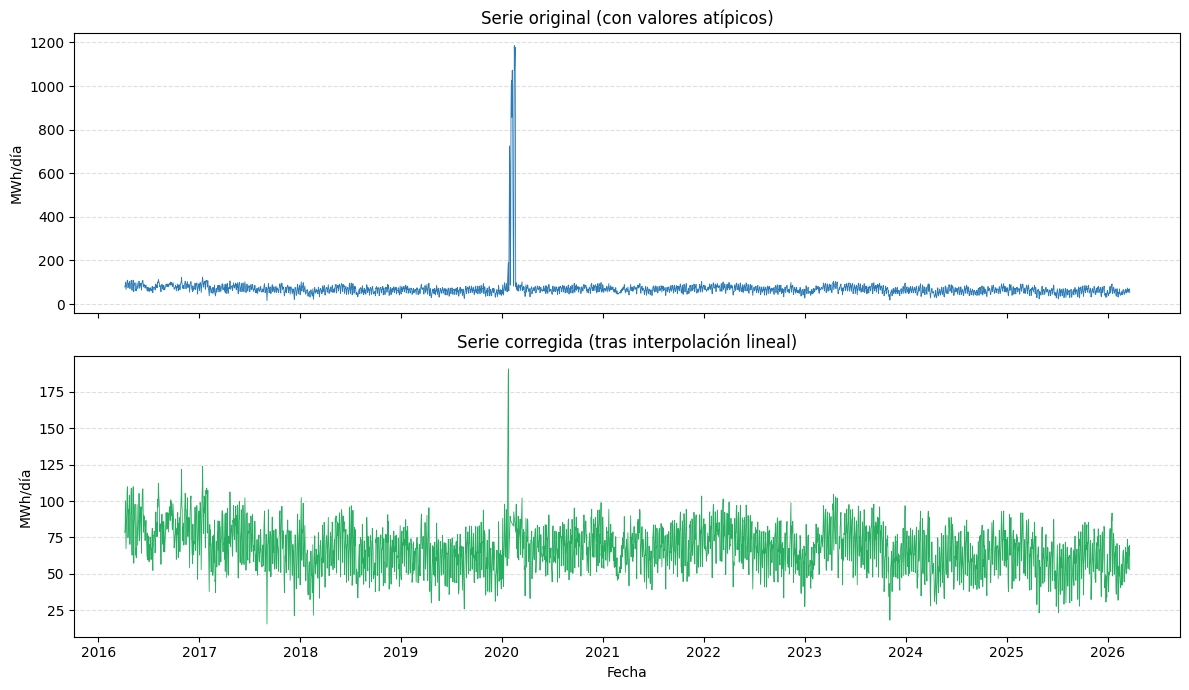

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
# Panel superior: serie original
ax1.plot(df_biogas["datetime"], df_biogas["generacion_biogas_mwh"],
         linewidth=0.6, color="#2c7bb6")
ax1.set_title("Serie original (con valores atípicos)")
ax1.set_ylabel("MWh/día")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
# Panel inferior: serie corregida
ax2.plot(df_biogas["datetime"], df_biogas["generacion_corregida"],
         linewidth=0.6, color="#27ae60")
ax2.set_title("Serie corregida (tras interpolación lineal)")
ax2.set_ylabel("MWh/día")
ax2.set_xlabel("Fecha")
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_serie_antes_despues.png", dpi=150, bbox_inches="tight")
plt.show()
# Desde aquí se trabaja el EDA con la serie corregida
df_biogas["generacion_biogas_mwh"] = df_biogas["generacion_corregida"]

**Distribución de los valores de generación**

El histograma muestra cuántos días hay en cada rango de generación.
La curva KDE (estimación de densidad) suaviza el histograma para ver mejor
la forma global de la distribución: si es simétrica, si tiene colas, etc.
Se hace sobre la serie ya corregida.

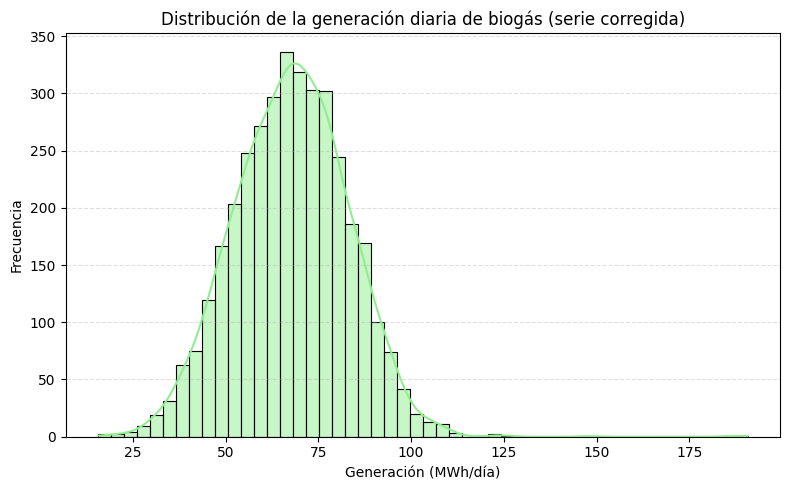

Asimetría (skewness): 0.270
Curtosis:             1.949


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Histograma con 50 barras y curva KDE, que suaviza esa información para revelar la forma continua de la distribución sin depender del tamaño de los intervalos
sns.histplot(df_biogas["generacion_biogas_mwh"], bins=50, kde=True,
             color="#90EE90", ax=ax)

ax.set_xlabel("Generación (MWh/día)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la generación diaria de biogás (serie corregida)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticos de forma
from scipy.stats import skew, kurtosis
print(f"Asimetría (skewness): {skew(df_biogas['generacion_biogas_mwh']):.3f}")
print(f"Curtosis:             {kurtosis(df_biogas['generacion_biogas_mwh']):.3f}")

**Patrones estacionales con representación boxplot por mes y por día de la semana**

Un boxplot por mes muestra si la generación varía según la época del año.
Un boxplot por día de la semana muestra si hay un patrón dentro de la semana.
Estos patrones orientan el diseño de los modelos y la elección de la ventana temporal.

/tmp/ipykernel_6356/927075638.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_mes, labels=nombres_meses, patch_artist=True,


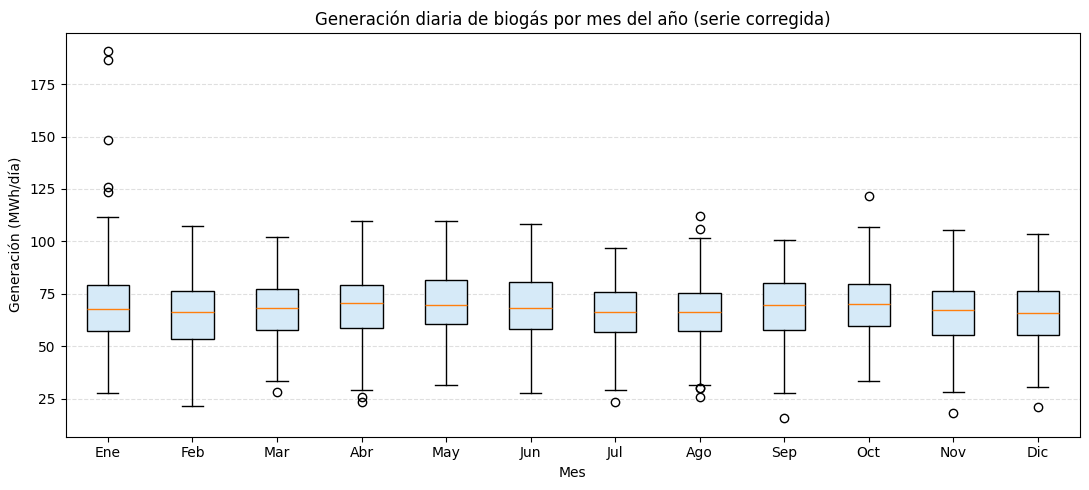

/tmp/ipykernel_6356/927075638.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_dia, labels=nombres_dias, patch_artist=True,


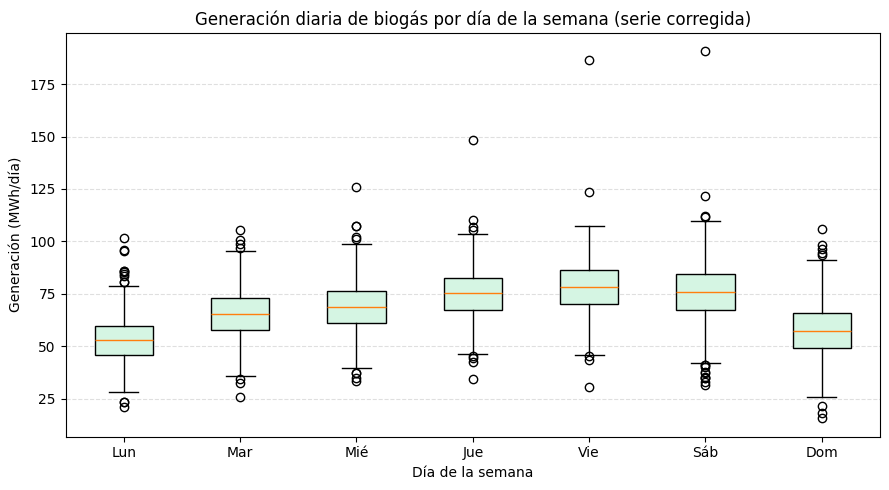

In [ ]:
# Crear columnas auxiliares de tiempo
df_biogas["mes"] = df_biogas["datetime"].dt.month
df_biogas["dia_semana"] = df_biogas["datetime"].dt.dayofweek  # 0 = lunes, 6 = domingo

nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
nombres_dias  = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]

# --- Boxplot por mes ---
datos_mes = [df_biogas[df_biogas["mes"] == m]["generacion_biogas_mwh"].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(datos_mes, labels=nombres_meses, patch_artist=True,
           boxprops=dict(facecolor="#d6eaf8"))
ax.set_xlabel("Mes")
ax.set_ylabel("Generación (MWh/día)")
ax.set_title("Generación diaria de biogás por mes del año (serie corregida)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_boxplot_mes.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Boxplot por día de la semana ---
datos_dia = [df_biogas[df_biogas["dia_semana"] == d]["generacion_biogas_mwh"].values for d in range(7)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(datos_dia, labels=nombres_dias, patch_artist=True,
           boxprops=dict(facecolor="#d5f5e3"))
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Generación (MWh/día)")
ax.set_title("Generación diaria de biogás por día de la semana (serie corregida)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_boxplot_dia_semana.png", dpi=150, bbox_inches="tight")
plt.show()

**Evolución interanual con boxplot y media por año**

Se agrupan los datos por año para ver si la generación ha subido, bajado o se
ha mantenido estable a lo largo del periodo.
Solo se usan años con los 12 meses completos para que la comparación sea justa.

/tmp/ipykernel_6356/1350660041.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_año, labels=[str(a) for a in años_completos], patch_artist=True,


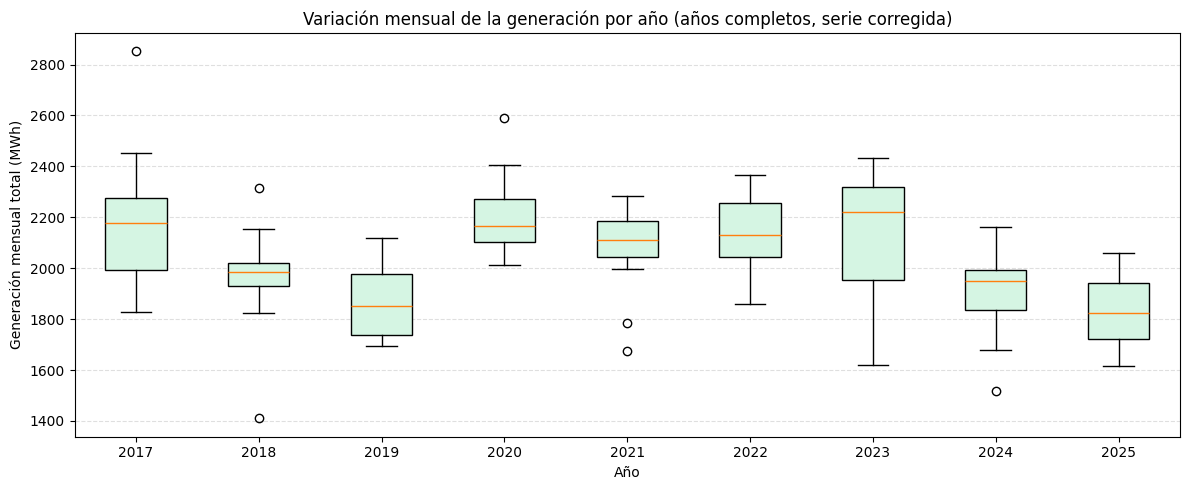

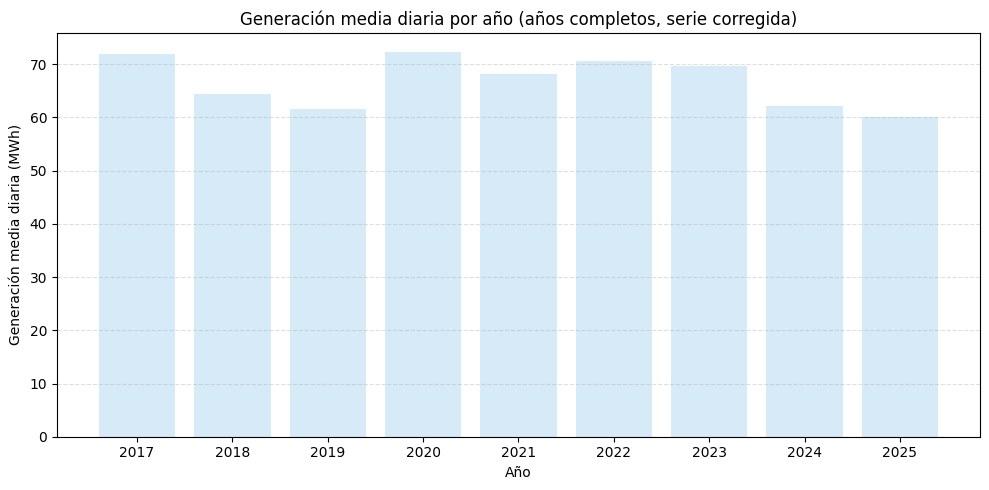

In [ ]:
df_biogas["año"] = df_biogas["datetime"].dt.year

# Calcular generación mensual total (para el boxplot)
df_biogas["mes"] = df_biogas["datetime"].dt.month
df_mensual = df_biogas.groupby(["año", "mes"])["generacion_biogas_mwh"].sum().reset_index()

# Seleccionar solo años con 12 meses completos
meses_por_año = df_mensual.groupby("año")["mes"].nunique()
años_completos = meses_por_año[meses_por_año == 12].index.tolist()
df_mensual_ok = df_mensual[df_mensual["año"].isin(años_completos)]

# --- Boxplot por año ---
datos_año = [df_mensual_ok[df_mensual_ok["año"] == a]["generacion_biogas_mwh"].values
             for a in años_completos]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(datos_año, labels=[str(a) for a in años_completos], patch_artist=True,
           boxprops=dict(facecolor="#d5f5e3"))
ax.set_xlabel("Año")
ax.set_ylabel("Generación mensual total (MWh)")
ax.set_title("Variación mensual de la generación por año (años completos, serie corregida)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_boxplot_ano.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Gráfico de barras: media diaria por año ---
df_ok = df_biogas[df_biogas["año"].isin(años_completos)]
media_anual = df_ok.groupby("año")["generacion_biogas_mwh"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(media_anual)), media_anual.values, color="#d6eaf8")
ax.set_xticks(range(len(media_anual)))
ax.set_xticklabels([str(a) for a in media_anual.index])
ax.set_xlabel("Año")
ax.set_ylabel("Generación media diaria (MWh)")
ax.set_title("Generación media diaria por año (años completos, serie corregida)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_barras_media_anual.png", dpi=150, bbox_inches="tight")
plt.show()

**Tendencia y descomposición estacional**

La media móvil de 30 días elimina el ruido diario y deja ver la tendencia general.
La descomposición aditiva separa la serie en tres partes: tendencia, estacionalidad
anual y residuo. Esto confirma si hay ciclos repetitivos que los modelos deben aprender.

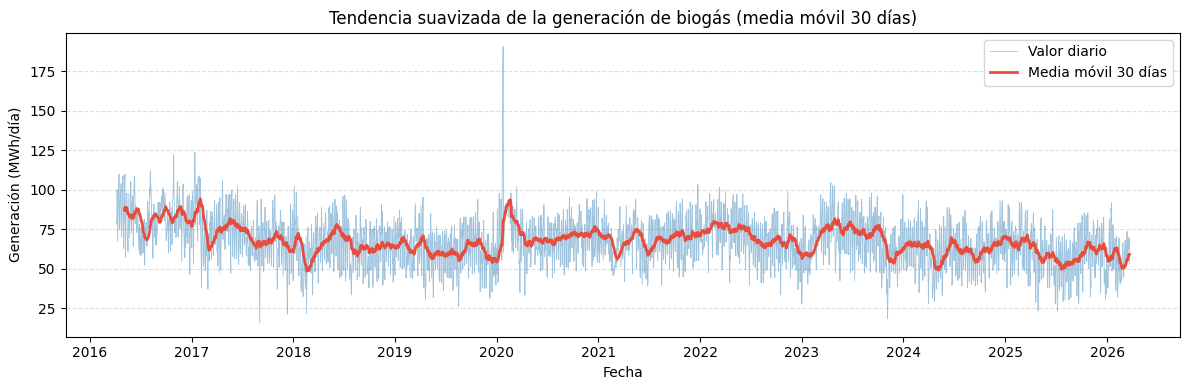

In [ ]:
# --- Media móvil de 30 días ---
# window=30: cada valor es la media de los 30 días anteriores
df_biogas["media_movil_30d"] = df_biogas["generacion_biogas_mwh"].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_biogas["datetime"], df_biogas["generacion_biogas_mwh"],
        linewidth=0.6, color="#2c7bb6", alpha=0.45, label="Valor diario")
ax.plot(df_biogas["datetime"], df_biogas["media_movil_30d"],
        linewidth=2, color="#e74c3c", label="Media móvil 30 días")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación (MWh/día)")
ax.set_title("Tendencia suavizada de la generación de biogás (media móvil 30 días)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_media_movil.png", dpi=150, bbox_inches="tight")
plt.show()

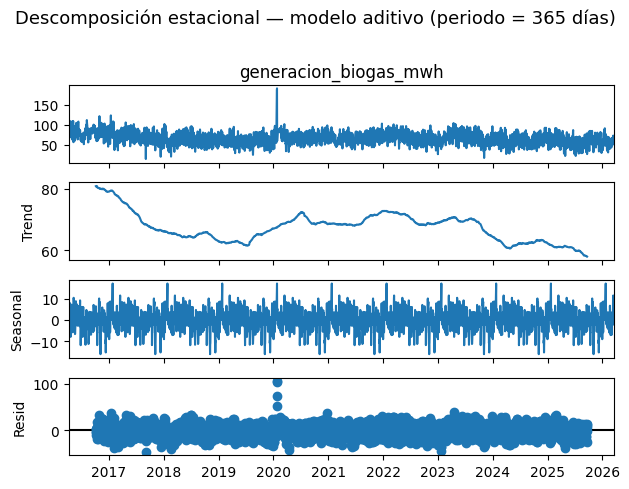

In [ ]:
# Poner datetime como índice (necesario para la descomposición)
serie = df_biogas.set_index("datetime")["generacion_biogas_mwh"]

# Descomposición aditiva con periodo anual (365 días)
# model='additive': asume que los componentes se suman (no multiplican)
resultado = seasonal_decompose(serie, model="additive", period=365)

resultado.plot()
plt.suptitle("Descomposición estacional — modelo aditivo (periodo = 365 días)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_descomposicion.png", dpi=150, bbox_inches="tight")
plt.show()

**Análisis de autocorrelación — ACF y PACF**

La ACF mide cuánto se parece la serie a sí misma desplazada en el tiempo.
La PACF hace lo mismo pero eliminando el efecto de los retardos intermedios.
Juntas indican cuántos días de historia son necesarios para predecir el siguiente valor,
lo que orienta la elección de la ventana temporal en los modelos.

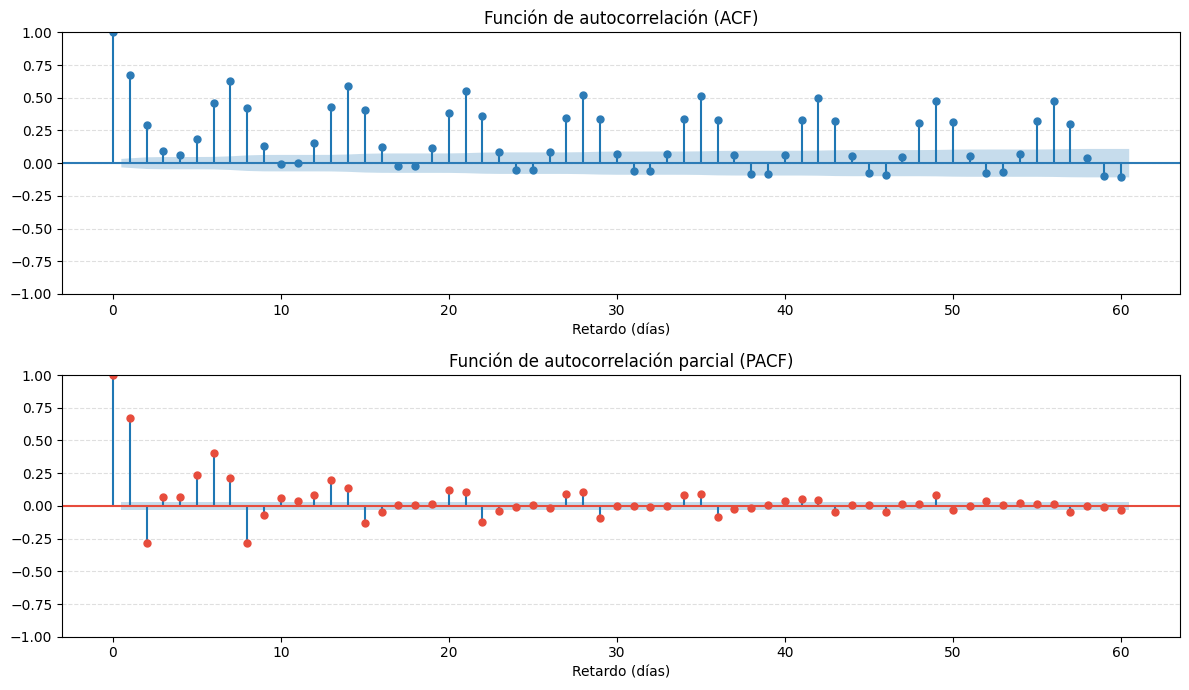

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# ACF: correlación con retardos de 1 a 60 días
plot_acf(df_biogas["generacion_biogas_mwh"], lags=60, ax=ax1, color="#2c7bb6")
ax1.set_title("Función de autocorrelación (ACF)")
ax1.set_xlabel("Retardo (días)")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# PACF: correlación parcial con retardos de 1 a 60 días
plot_pacf(df_biogas["generacion_biogas_mwh"], lags=60, ax=ax2, color="#e74c3c")
ax2.set_title("Función de autocorrelación parcial (PACF)")
ax2.set_xlabel("Retardo (días)")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

**Mapa de calor de generación mensual**

Se suma la generación de cada mes de cada año y se representa en una tabla de colores.
El eje Y son los años y el eje X son los meses.
El color más oscuro indica más generación.
Solo se incluyen años con los 12 meses completos para que la comparación sea válida.
Es el cierre del EDA: permite ver a la vez estacionalidad y tendencia interanual. YlGnBu

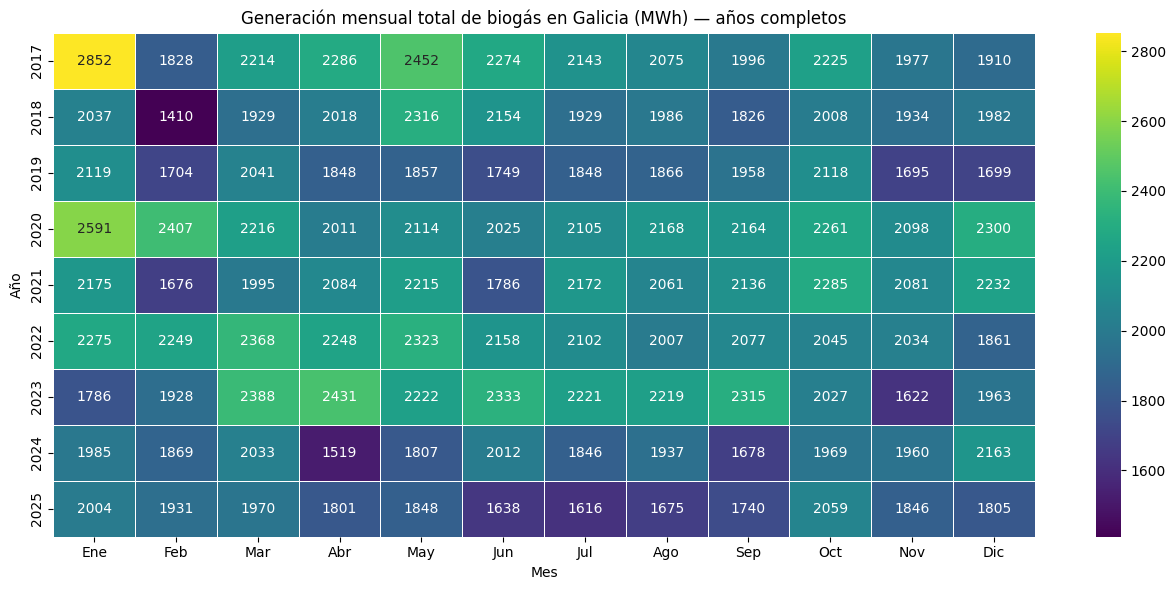

In [ ]:

# Generación mensual total
df_biogas["año"] = df_biogas["datetime"].dt.year
df_biogas["mes"] = df_biogas["datetime"].dt.month

# Solo años completos (12 meses)
meses_por_año = df_mensual.groupby("año")["mes"].nunique()
años_completos = meses_por_año[meses_por_año == 12].index.tolist()
df_heatmap = df_mensual[df_mensual["año"].isin(años_completos)]

# Tabla pivotada: filas = años, columnas = meses
tabla = df_heatmap.pivot(index="año", columns="mes", values="generacion_biogas_mwh")
tabla.columns = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(tabla, annot=True, fmt=".0f", cmap="viridis",
            linewidths=0.5, ax=ax)
ax.set_title("Generación mensual total de biogás en Galicia (MWh) — años completos")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.tight_layout()
plt.savefig("fig_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()